# RAG Knowledge Base Builder — Diabetes Management

## Step 1: Setup — Libraries Install Karna

Is project mein hum ye libraries use karenge:
- **pypdf** — PDF files se text nikaalne ke liye
- **sentence-transformers** — text ko embeddings (numbers) mein convert karne ke liye
- **chromadb** — embeddings store aur search karne ke liye (vector database)
- **langchain-text-splitters** — recursive chunking ke liye

Ye sab ek baar install karne honge Colab session mein.

In [ ]:
!pip install pypdf sentence-transformers chromadb langchain-text-splitters -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6

## Step 2: Upload Your Guidelines Folder

Since the files are stored locally on your computer (not Google Drive),
we'll upload them directly to this Colab session.

**Before running the cell below:**
1. On your computer, right-click the `guidelines` folder →
   "Compress to ZIP" (Windows) or "Compress" (Mac)
2. This will create a file like `guidelines.zip`

Running the cell below will open an upload button — select that zip file.

**Note:** Files uploaded this way are temporary — they'll be deleted when
this Colab session ends. You'll need to re-upload if you restart the
runtime later.

In [ ]:
from google.colab import files
import zipfile
import os

# This will open a file picker — select your guidelines.zip file
uploaded = files.upload()

# Get the uploaded zip filename automatically
zip_filename = list(uploaded.keys())[0]

# Unzip it into the Colab environment
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print(f"\n✅ Extracted '{zip_filename}' successfully!")
print("\nFolder structure:")
for root, dirs, filenames in os.walk('/content/guidelines'):
    level = root.replace('/content/guidelines', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in filenames:
        print(f'{indent}  {f}')

Saving guidelines.zip to guidelines.zip

✅ Extracted 'guidelines.zip' successfully!

Folder structure:
guidelines/
  research_paper/
    research_paper_ml_based_30_day_readmission_of_type_2_of_elderly_diabetes_patient_with_mellitus_and_heart_failure_cohort_of_SHAP_study_and_interpretibility_analysis.pdf
    research_paper_development_and_balidation_of_arisk_prediction_model_for_30_day_readmission_in_elderly_type_2_diabetes_patient_complicated_with_heart_failure_.pdf
  mayo/
    mayo_diabetes_diet_create_your_healthy_eating_plan.pdf
    mayo_type_2_diabetes_diagnosis_and_treatment.pdf
    mayo_diabetes_and_exercise_when_to_monitor_your_blood_sugar.pdf
    mayo_diabetes_symptoms_when_diabetes_symptoms_are_a_concern.pdf
    mayo_A1C_test.pdf
    mayo_diabetes_treatment_medications_for_type_2_diabetes.pdf
    mayo_type_2_diabetes_symptoms_and_causes.pdf
    mayo_glucose_tolerance_test.pdf
    mayo_diabetes_management_how_lifestyle_daily_routine_affect_blood_sugar.pdf
  ada/
    ada_index.p

## Step 3: Extract Text and Check for Duplicates/Corruption

Before running the (time-consuming) chunking step, we first extract raw
text from every file and run two quick checks:
1. **Duplicate detection** — comparing a hash (fingerprint) of each
   file's text to catch exact duplicates
2. **Corruption detection** — checking if the extracted text looks like
   readable content or garbage (e.g., raw PDF binary data)

This lets us clean the file list *before* chunking, so chunking only
needs to run once on the final, clean set of documents.

In [ ]:
import os
import hashlib
from pathlib import Path
from pypdf import PdfReader

GUIDELINES_FOLDER = "/content/guidelines"
SOURCE_FOLDERS = {
    "ada": "ADA",
    "who": "WHO",
    "cdc": "CDC",
    "mayo": "Mayo Clinic",
    "research_paper": "Research Paper",
}

def extract_text_from_pdf(pdf_path: Path) -> str:
    try:
        reader = PdfReader(str(pdf_path))
        text = ""
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n\n"
        return text
    except Exception as e:
        print(f"  Error reading {pdf_path.name}: {e}")
        return ""

def extract_text_from_txt(txt_path: Path) -> str:
    try:
        return txt_path.read_text(encoding="utf-8", errors="ignore")
    except Exception as e:
        print(f"  Error reading {txt_path.name}: {e}")
        return ""

def is_likely_corrupt(text: str) -> bool:
    if not text.strip():
        return True
    if text.strip().startswith("%PDF"):
        return True
    sample = text[:500]
    printable_ratio = sum(c.isalnum() or c.isspace() for c in sample) / max(len(sample), 1)
    return printable_ratio < 0.5

# ------------------------------------------------------------------
# Extract text from every file + collect hashes for duplicate check
# ------------------------------------------------------------------
file_records = []  # list of dicts: {path, source, text, hash, is_corrupt}
base_path = Path(GUIDELINES_FOLDER)

for folder_name, source_label in SOURCE_FOLDERS.items():
    folder_path = base_path / folder_name
    if not folder_path.exists():
        continue

    files = list(folder_path.glob("*.pdf")) + list(folder_path.glob("*.txt"))
    for file_path in files:
        if file_path.suffix.lower() == ".pdf":
            text = extract_text_from_pdf(file_path)
        else:
            text = extract_text_from_txt(file_path)

        text_hash = hashlib.md5(text.strip().encode(errors="ignore")).hexdigest()
        corrupt = is_likely_corrupt(text)

        file_records.append({
            "path": file_path,
            "filename": file_path.name,
            "source": source_label,
            "text": text,
            "hash": text_hash,
            "is_corrupt": corrupt,
        })

# ------------------------------------------------------------------
# Report: Corrupt files
# ------------------------------------------------------------------
print("=" * 60)
print("CORRUPT / UNREADABLE FILES")
print("=" * 60)
corrupt_files = [r for r in file_records if r["is_corrupt"]]
if corrupt_files:
    for r in corrupt_files:
        print(f"  - {r['filename']} (source: {r['source']})")
else:
    print("  None found")

# ------------------------------------------------------------------
# Report: Duplicate files (same hash)
# ------------------------------------------------------------------
print("\n" + "=" * 60)
print("DUPLICATE FILES (identical content)")
print("=" * 60)
seen_hashes = {}
duplicate_files = []
for r in file_records:
    if r["is_corrupt"]:
        continue  # skip corrupt files, hash not meaningful for them
    if r["hash"] in seen_hashes:
        print(f"  - '{r['filename']}' is a duplicate of '{seen_hashes[r['hash']]}'")
        duplicate_files.append(r)
    else:
        seen_hashes[r["hash"]] = r["filename"]

if not duplicate_files:
    print("  None found")

print(f"\nTotal files scanned: {len(file_records)}")
print(f"Corrupt files: {len(corrupt_files)}")
print(f"Duplicate files: {len(duplicate_files)}")

CORRUPT / UNREADABLE FILES
  None found

DUPLICATE FILES (identical content)
  None found

Total files scanned: 54
Corrupt files: 0
Duplicate files: 0


## Step 4: Extract Text and Apply Recursive Chunking

Now we'll process every file in the `guidelines` folder:
1. Extract raw text from each PDF (or read `.txt` files directly)
2. Split the text into chunks using **recursive chunking** —
   splitting first by paragraph, then sentence, then word, until
   each chunk fits our target size
3. Attach metadata to each chunk (source organization, filename)
   so we can cite it later

**Settings used** (based on our earlier discussion):
- Chunk size: ~350 words
- Overlap: ~60 words

Files that can't be read (e.g., the JPG mistakenly saved instead of PDF)
will be skipped with a warning, rather than stopping the whole pipeline.

In [ ]:
import os
from pathlib import Path
from pypdf import PdfReader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
GUIDELINES_FOLDER = "/content/guidelines"
CHUNK_SIZE_WORDS = 350
CHUNK_OVERLAP_WORDS = 60

SOURCE_FOLDERS = {
    "ada": "ADA",
    "who": "WHO",
    "cdc": "CDC",
    "mayo": "Mayo Clinic",
    "research_paper": "Research Paper",
}

# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------
def extract_text_from_pdf(pdf_path: Path) -> str:
    try:
        reader = PdfReader(str(pdf_path))
        text = ""
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n\n"
        return text
    except Exception as e:
        print(f"    Error reading {pdf_path.name}: {e}")
        return ""

def extract_text_from_txt(txt_path: Path) -> str:
    try:
        return txt_path.read_text(encoding="utf-8", errors="ignore")
    except Exception as e:
        print(f"    Error reading {txt_path.name}: {e}")
        return ""

def create_chunks(text: str, chunk_size_words: int, overlap_words: int) -> list[str]:
    chars_per_word = 6  # rough average for English/medical text
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size_words * chars_per_word,
        chunk_overlap=overlap_words * chars_per_word,
        separators=["\n\n", "\n", ". ", " ", ""],
        length_function=len,
    )
    return splitter.split_text(text)

# ------------------------------------------------------------------
# Main processing loop
# ------------------------------------------------------------------
all_chunks = []
base_path = Path(GUIDELINES_FOLDER)
skipped_files = []

for folder_name, source_label in SOURCE_FOLDERS.items():
    folder_path = base_path / folder_name
    if not folder_path.exists():
        print(f"  Folder not found, skipping: {folder_path}")
        continue

    print(f"\n Processing: {source_label}")

    files = list(folder_path.glob("*.pdf")) + list(folder_path.glob("*.txt"))

    for file_path in files:
        print(f"   Reading: {file_path.name}")

        if file_path.suffix.lower() == ".pdf":
            text = extract_text_from_pdf(file_path)
        else:
            text = extract_text_from_txt(file_path)

        if not text.strip():
            print(f"       No extractable text — skipping this file")
            skipped_files.append(file_path.name)
            continue

        chunks = create_chunks(text, CHUNK_SIZE_WORDS, CHUNK_OVERLAP_WORDS)
        print(f"      {len(chunks)} chunks created")

        for i, chunk_text in enumerate(chunks):
            all_chunks.append({
                "text": chunk_text,
                "source": source_label,
                "filename": file_path.name,
                "chunk_index": i,
                "chunk_id": f"{file_path.stem}_{i}",
            })

# ------------------------------------------------------------------
# Summary
# ------------------------------------------------------------------
print("\n" + "=" * 60)
print(f" Total chunks created: {len(all_chunks)}")
print(f"  Files skipped (unreadable): {len(skipped_files)}")
if skipped_files:
    for f in skipped_files:
        print(f"   - {f}")
print("=" * 60)


 Processing: ADA
   Reading: ada_index.pdf
      41 chunks created
   Reading: ada_standards_of_care_in_diabetes_2026_abridged.pdf
      3 chunks created
   Reading: ada_section_11_chronic_kidney_disease_and_risk_management.pdf
      4 chunks created
   Reading: ada_obesity_and_weight_management_for_the_prevention.pdf
      73 chunks created
   Reading: ada_retinopathy_neuropathy_and_foot_care_standards.pdf
      71 chunks created
   Reading: ada_section_5_facilitating_positive_health_behaviors.pdf
      8 chunks created
   Reading: ada_introduction_to_methodology.pdf
      19 chunks created
   Reading: ada_prevention_or_delay_of_diabetes_and_associated_comorbidities.pdf
      49 chunks created
   Reading: ada_section_9_pharmacologic_approaches_to_glycemic_treatment.pdf
      7 chunks created
   Reading: ada_diagnosis_and_classification_of_diabetes.pdf
      102 chunks created
   Reading: ada_asection_16_diabetes_care_in_the_hospital.pdf
      4 chunks created
   Reading: ada_cardiova

      8 chunks created
   Reading: who_list_of_priority_medical_devices_(CVD_and_diabetes).pdf
      230 chunks created

 Processing: CDC
   Reading: cdc_ndep.pdf
      89 chunks created
   Reading: cdcDSMES_toolkit_diabetes_Self-management_education_and_support.pdf
      3 chunks created
   Reading: cdc_prevent_type2_diabetes.pdf
      2 chunks created
   Reading: cdc_referring_patients_to_DSMES.pdf
      2 chunks created
   Reading: cdc_clinical_guidance_for_diabetes.pdf
      3 chunks created
   Reading: cdc_diabetes_self_management.pdf
      55 chunks created
   Reading: cdc_centre_for_disease_control_and_prevention_national_centre_for_chronic_disease_prevention_and_health_promotion.pdf
      25 chunks created
   Reading: cdc_guiding_principles_for_the_care_of_people_with_or_at_risk_for_diabetes.pdf
      144 chunks created

 Processing: Mayo Clinic
   Reading: mayo_diabetes_diet_create_your_healthy_eating_plan.pdf
      8 chunks created
   Reading: mayo_type_2_diabetes_diagnosis_a

## Step 5: Generate Embeddings and Store in a Vector Database

Now that we have clean, chunked text (~2456 chunks), we convert each
chunk into a numerical vector (embedding) using a pre-trained model,
and store these vectors in Chroma — a vector database that lets us
later search for the most relevant chunks based on meaning, not just
keywords.

**Model used**: `all-MiniLM-L6-v2` — a free, lightweight embedding model
that produces 384-dimensional vectors.

**Note**: This step may take a few minutes depending on chunk count
and Colab's available resources (using a GPU runtime speeds this up
significantly — check Runtime > Change runtime type > GPU if available).

In [ ]:
from sentence_transformers import SentenceTransformer
import chromadb

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
EMBEDDING_MODEL = "all-MiniLM-L6-v2"
VECTOR_DB_PATH = "/content/chroma_db"
COLLECTION_NAME = "diabetes_guidelines"

# ------------------------------------------------------------------
# Load embedding model
# ------------------------------------------------------------------
print(f"Loading embedding model: {EMBEDDING_MODEL} ...")
model = SentenceTransformer(EMBEDDING_MODEL)
print("Model loaded.\n")

# ------------------------------------------------------------------
# Set up Chroma vector database
# ------------------------------------------------------------------
print(f"Setting up Chroma database at: {VECTOR_DB_PATH} ...")
client = chromadb.PersistentClient(path=VECTOR_DB_PATH)
collection = client.get_or_create_collection(name=COLLECTION_NAME)

# ------------------------------------------------------------------
# Prepare data for embedding
# ------------------------------------------------------------------
texts = [c["text"] for c in all_chunks]
ids = [c["chunk_id"] for c in all_chunks]
metadatas = [
    {
        "source": c["source"],
        "filename": c["filename"],
        "chunk_index": c["chunk_index"],
    }
    for c in all_chunks
]

print(f"\nGenerating embeddings for {len(texts)} chunks (this may take a few minutes)...")
embeddings = model.encode(texts, show_progress_bar=True, batch_size=32)

# ------------------------------------------------------------------
# Store in Chroma
# ------------------------------------------------------------------
collection.add(
    ids=ids,
    embeddings=embeddings.tolist(),
    documents=texts,
    metadatas=metadatas,
)

print(f"\nDone! {len(texts)} chunks stored in the vector database.")
print(f"Total items in collection: {collection.count()}")

Loading embedding model: all-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.

Setting up Chroma database at: /content/chroma_db ...

Generating embeddings for 2455 chunks (this may take a few minutes)...


Batches:   0%|          | 0/77 [00:00<?, ?it/s]


Done! 2455 chunks stored in the vector database.
Total items in collection: 2455


## Step 6: Test Retrieval

Let's verify the vector database works by running a sample query and
checking whether it returns relevant chunks from the right sources.

In [ ]:
def test_retrieval(query: str, top_k: int = 5):
    query_embedding = model.encode([query]).tolist()

    results = collection.query(
        query_embeddings=query_embedding,
        n_results=top_k,
    )

    print(f"Query: '{query}'\n")
    print(f"Top {top_k} relevant chunks:\n")

    for i in range(len(results["documents"][0])):
        doc = results["documents"][0][i]
        meta = results["metadatas"][0][i]
        distance = results["distances"][0][i]
        similarity = 1 - distance

        print(f"Rank {i+1} | Source: {meta['source']} | File: {meta['filename']} | Similarity: {similarity:.3f}")
        print(f"Text: {doc[:250]}...")
        print()

# Try a sample query relevant to your project
test_retrieval("What should be included in a discharge plan for a high-risk diabetes patient?")

Query: 'What should be included in a discharge plan for a high-risk diabetes patient?'

Top 5 relevant chunks:

Rank 1 | Source: ADA | File: ada_asection_16_diabetes_care_in_the_hospital.pdf | Similarity: 0.468
Text: Transition From the Hospital to the Ambulatory Setting
Tailor a structured discharge plan to the individual with diabetes:
Transmit discharge summaries to the primary care clinician as soon as possible after discharge.
Provide diabetes self-managemen...

Rank 2 | Source: ADA | File: ada_diabetes_care_in_hospital.pdf | Similarity: 0.464
Text: of new and old prescriptions, that no 
chronic medications are stopped, and 
that there is no duplication of medica
-
tions under different brand names.
• Prescriptions for new or changed medi-
cations should be filled and reviewed 
with the individu...

Rank 3 | Source: ADA | File: ada_diabetes_care_in_hospital.pdf | Similarity: 0.327
Text: -
abetes management. E
A structured discharge plan tailored to 
the individual may reduce the l

## Step 7: Visualizing Chunk Embeddings

To verify that our embeddings genuinely capture topic-level meaning
(and not just surface-level word overlap), we reduce the 384-dimensional
vectors to 2D using PCA, and plot a sample of chunks color-coded by
source. If embeddings are working correctly, chunks discussing similar
topics should cluster closer together, and unrelated topics should
appear farther apart.

We also plot our test query on the same graph to visually confirm it
falls near its retrieved (relevant) chunks.

Sampled 200 chunks across 5 sources


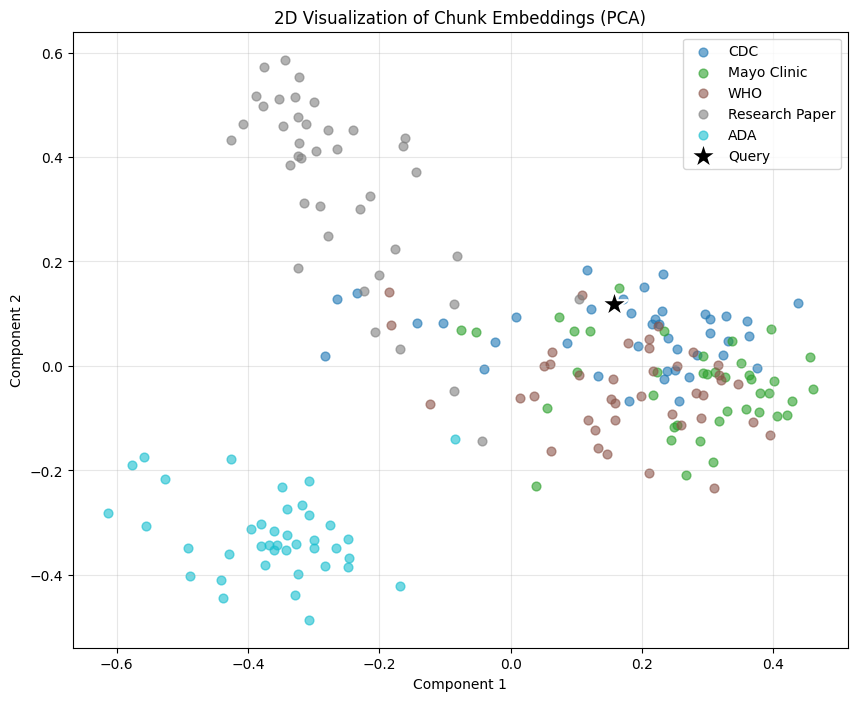

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ------------------------------------------------------------------
# Take a sample of chunks across sources (visualizing all 2456
# would be too cluttered)
# ------------------------------------------------------------------
sample_size_per_source = 40
sampled_chunks = []
sources_seen = {}

for c in all_chunks:
    src = c["source"]
    sources_seen.setdefault(src, 0)
    if sources_seen[src] < sample_size_per_source:
        sampled_chunks.append(c)
        sources_seen[src] += 1

print(f"Sampled {len(sampled_chunks)} chunks across {len(sources_seen)} sources")

# ------------------------------------------------------------------
# Get embeddings for the sample + our test query
# ------------------------------------------------------------------
sample_texts = [c["text"] for c in sampled_chunks]
sample_sources = [c["source"] for c in sampled_chunks]

query_text = "What should be included in a discharge plan for a high-risk diabetes patient?"

sample_embeddings = model.encode(sample_texts)
query_embedding = model.encode([query_text])

# Combine chunks + query for joint dimensionality reduction
all_embeddings = np.vstack([sample_embeddings, query_embedding])

# ------------------------------------------------------------------
# Reduce to 2D using PCA
# ------------------------------------------------------------------
pca = PCA(n_components=2)
reduced = pca.fit_transform(all_embeddings)

chunk_points = reduced[:-1]  # all except last
query_point = reduced[-1]    # last one is the query

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(10, 8))

unique_sources = list(set(sample_sources))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_sources)))
color_map = dict(zip(unique_sources, colors))

for src in unique_sources:
    idx = [i for i, s in enumerate(sample_sources) if s == src]
    plt.scatter(chunk_points[idx, 0], chunk_points[idx, 1],
                label=src, alpha=0.6, s=40, color=color_map[src])

# Plot the query as a distinct marker
plt.scatter(query_point[0], query_point[1],
            color='black', marker='*', s=400, label='Query', edgecolors='white', linewidth=1.5)

plt.title("2D Visualization of Chunk Embeddings (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Graph 2: Query vs Actual Top-5 Retrieved Chunks

The graph above shows the *overall* topical layout of a random sample —
it does not guarantee that the truly relevant chunks (as identified by
Chroma's similarity search) will visually appear close to the query in
this reduced 2D space. To directly verify retrieval quality, we now
highlight the actual top-5 chunks returned by our retrieval test on the
same plot.

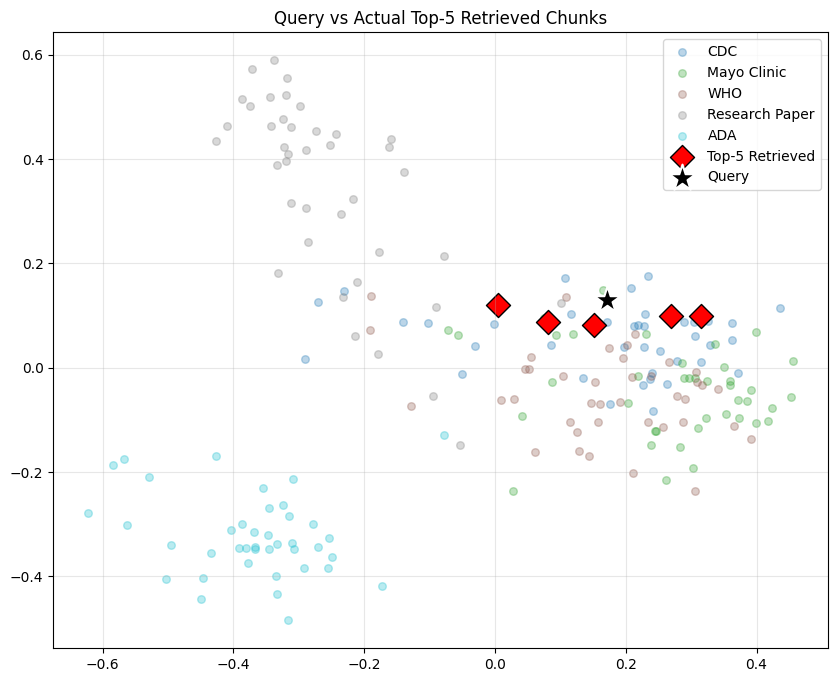

In [ ]:
# Get the actual top-5 retrieved chunks from Chroma
results = collection.query(query_embeddings=model.encode([query_text]).tolist(), n_results=5)
retrieved_ids = results["ids"][0]

# Mark which sampled points are the actual retrieved ones
retrieved_texts = results["documents"][0]
retrieved_embeddings = model.encode(retrieved_texts)

# Add these to the visualization with a distinct marker
all_embeddings_v2 = np.vstack([sample_embeddings, retrieved_embeddings, query_embedding])
reduced_v2 = PCA(n_components=2).fit_transform(all_embeddings_v2)

n_sample = len(sample_embeddings)
n_retrieved = len(retrieved_embeddings)

chunk_points_v2 = reduced_v2[:n_sample]
retrieved_points_v2 = reduced_v2[n_sample:n_sample+n_retrieved]
query_point_v2 = reduced_v2[-1]

plt.figure(figsize=(10, 8))
for src in unique_sources:
    idx = [i for i, s in enumerate(sample_sources) if s == src]
    plt.scatter(chunk_points_v2[idx, 0], chunk_points_v2[idx, 1],
                label=src, alpha=0.3, s=30, color=color_map[src])

plt.scatter(retrieved_points_v2[:, 0], retrieved_points_v2[:, 1],
            color='red', marker='D', s=150, label='Top-5 Retrieved', edgecolors='black', linewidth=1)
plt.scatter(query_point_v2[0], query_point_v2[1],
            color='black', marker='*', s=400, label='Query', edgecolors='white', linewidth=1.5)

plt.title("Query vs Actual Top-5 Retrieved Chunks")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 8: Personalization Layer

Before combining retrieval with an LLM, we first build and test the
personalization logic on its own. This layer takes structured patient
data (the kind our readmission prediction model would output) and
converts it into two things:

1. A **readable text summary** of the patient's profile
2. A set of **rule-based risk flags** — explicit signals for conditions
   that should be prioritized in any recommendation (e.g., high
   readmission risk, polypharmacy)

We test this

In [ ]:
# ------------------------------------------------------------------
# Sample patient data — this would come from your readmission
# prediction model's output in a real integration
# ------------------------------------------------------------------
patient_context = {
    "risk_score": 0.68,
    "prior_admissions": 3,
    "num_medications": 12,
    "discharge_disposition": "Home",
    "a1c_level": "High",
}

# ------------------------------------------------------------------
# Derive a readable risk level from the numeric score
# ------------------------------------------------------------------
def get_risk_level(risk_score: float) -> str:
    if risk_score >= 0.6:
        return "High"
    elif risk_score >= 0.3:
        return "Moderate"
    else:
        return "Low"

# ------------------------------------------------------------------
# Convert patient data into a readable text summary
# ------------------------------------------------------------------
def format_patient_context(patient_context: dict) -> str:
    risk_level = get_risk_level(patient_context["risk_score"])
    summary = f"""Patient Risk Profile:
- Readmission risk: {risk_level} ({patient_context['risk_score']*100:.0f}%)
- Prior hospital admissions (past year): {patient_context['prior_admissions']}
- Current medication count: {patient_context['num_medications']}
- Discharge destination: {patient_context['discharge_disposition']}
- A1C control: {patient_context['a1c_level']}"""
    return summary

# ------------------------------------------------------------------
# Rule-based flags — explicit signals for the LLM to prioritize
# ------------------------------------------------------------------
def get_risk_flags(patient_context: dict) -> list:
    flags = []

    if patient_context["risk_score"] >= 0.6:
        flags.append("HIGH READMISSION RISK — prioritize early follow-up (within 7 days)")

    if patient_context["num_medications"] > 10:
        flags.append("POLYPHARMACY CONCERN — medication reconciliation is critical")

    if patient_context["discharge_disposition"] == "Home" and patient_context["prior_admissions"] > 2:
        flags.append("HOME DISCHARGE WITH HISTORY OF REPEAT ADMISSIONS — consider home health referral")

    if patient_context["a1c_level"] == "High":
        flags.append("POOR GLYCEMIC CONTROL — reinforce diabetes self-management education")

    return flags

# ------------------------------------------------------------------
# Test it
# ------------------------------------------------------------------
summary_text = format_patient_context(patient_context)
flags = get_risk_flags(patient_context)

print("=== Patient Context Summary ===")
print(summary_text)

print("\n=== Risk Flags ===")
if flags:
    for f in flags:
        print(f"  - {f}")
else:
    print("  No flags triggered.")

=== Patient Context Summary ===
Patient Risk Profile:
- Readmission risk: High (68%)
- Prior hospital admissions (past year): 3
- Current medication count: 12
- Discharge destination: Home
- A1C control: High

=== Risk Flags ===
  - HIGH READMISSION RISK — prioritize early follow-up (within 7 days)
  - POLYPHARMACY CONCERN — medication reconciliation is critical
  - HOME DISCHARGE WITH HISTORY OF REPEAT ADMISSIONS — consider home health referral
  - POOR GLYCEMIC CONTROL — reinforce diabetes self-management education


Testing a low risk patient

In [ ]:
# Test with a low-risk patient — flags should mostly NOT trigger
low_risk_patient = {
    "risk_score": 0.15,
    "prior_admissions": 0,
    "num_medications": 4,
    "discharge_disposition": "Home",
    "a1c_level": "Controlled",
}

print(format_patient_context(low_risk_patient))
print("\nFlags:", get_risk_flags(low_risk_patient) or "None triggered")

Patient Risk Profile:
- Readmission risk: Low (15%)
- Prior hospital admissions (past year): 0
- Current medication count: 4
- Discharge destination: Home
- A1C control: Controlled

Flags: None triggered


## Step 8B: Connecting to Real Patient Data

The `patient_context` used above was typed in manually, just to test the
personalization logic in isolation. Now we connect it to something real:
the XGBoost model trained in the original `hospital_readmission.ipynb`
notebook (saved earlier as `.pkl` files), plus the raw patient dataset.

Upload these three files when prompted:
- `xgb_readmission_model.pkl`
- `model_columns.pkl`
- `diabetic_data.xlsx`

In [ ]:
from google.colab import files
import joblib
import pandas as pd
import re

# ------------------------------------------------------------------
# Upload: xgb_readmission_model.pkl, model_columns.pkl,
# and diabetic_data.xlsx (all three together)
# ------------------------------------------------------------------
uploaded = files.upload()

xgb_model_loaded = joblib.load('xgb_readmission_model.pkl')
model_columns = joblib.load('model_columns.pkl')
raw_df = pd.read_excel('diabetic_data.xlsx')

print("Model loaded successfully!")
print(f"Model expects {len(model_columns)} features")
print(f"Patient dataset shape: {raw_df.shape}")

Saving diabetic_data.xlsx to diabetic_data.xlsx
Saving model_columns.pkl to model_columns.pkl
Saving xgb_readmission_model.pkl to xgb_readmission_model.pkl
Model loaded successfully!
Model expects 189 features
Patient dataset shape: (101766, 50)


### Preprocessing a real patient row for prediction

`preprocess_patient()` mirrors the exact preprocessing steps from the
training notebook (dropping identifier/fairness-excluded columns, filling
missing values, grouping diagnosis codes, one-hot encoding, and aligning
to the model's expected columns) — so a raw row from `diabetic_data.xlsx`
can be fed straight into the trained model.

Rows missing a diagnosis code are filtered out first (`valid_rows`), since
the training pipeline required all three diagnosis fields to be present.

**Why this cleaning has to happen again here, even though the model was
already trained on cleaned data:** a saved model doesn't remember its
training data — the `.pkl` file only stores learned weights, not a memory
of past inputs. So every new patient, whether it's the 1st prediction or
the 1,000th, has to go through the *same* cleaning pipeline the training
data went through, every single time:

```python
# Training (once):     raw data      -> filter/clean -> train model -> save
# Prediction (every time): new patient -> SAME filter/clean -> trained model -> prediction
```

**Why diagnosis codes are dropped but other missing fields are just
filled in:** for fields like `payer_code`, "Unknown" is a genuinely valid
category the model can learn from. A missing diagnosis code can't be
filled the same way — diagnosis is the core clinical signal driving
readmission risk, and the training data followed this same drop-if-missing
rule, so prediction has to match it exactly.

**One extra step this notebook needs that training didn't:**

```python
df_encoded = df_encoded.reindex(columns=model_columns, fill_value=0)
```

Training one-hot encoded all 101,766 rows *together*, so every possible
category (every discharge type, every admission type) naturally became a
column. Here we're encoding a *single* patient row at a time — if that one
patient doesn't have a particular rare category, its column simply won't
get created, even though the trained model still expects it to exist.
`reindex()` fixes this by filling in any missing expected columns with 0,
so the final input always has the exact same 189 columns, in the exact
same order, that the model was trained on.

In [ ]:
import re
import pandas as pd

# ------------------------------------------------------------------
# Diagnosis code grouping (same as training notebook)
# ------------------------------------------------------------------
def map_diag(code):
    try:
        code = str(code)
        if code.startswith('V') or code.startswith('E'):
            return 'Other'
        code = float(code)
    except:
        return 'Other'
    if code == 250 or (250 <= code < 251):
        return 'Diabetes'
    elif 390 <= code <= 459 or code == 785:
        return 'Circulatory'
    elif 460 <= code <= 519 or code == 786:
        return 'Respiratory'
    elif 520 <= code <= 579 or code == 787:
        return 'Digestive'
    elif 800 <= code <= 999:
        return 'Injury'
    else:
        return 'Other'

# ------------------------------------------------------------------
# Preprocessing pipeline (same steps as training notebook)
# ------------------------------------------------------------------
def preprocess_patient(df_raw):
    df = df_raw.copy()
    df = df.drop(columns=['race', 'gender', 'weight', 'encounter_id', 'patient_nbr'], errors='ignore')
    df = df.replace('?', pd.NA)
    df['max_glu_serum'] = df['max_glu_serum'].fillna('Not Tested')
    df['A1Cresult'] = df['A1Cresult'].fillna('Not Tested')
    df['payer_code'] = df['payer_code'].fillna('Unknown')
    df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
    df = df.dropna(subset=['diag_1', 'diag_2', 'diag_3'])
    if 'readmitted' in df.columns:
        df = df.drop(columns=['readmitted'])
    for col in ['diag_1', 'diag_2', 'diag_3']:
        df[col] = df[col].apply(map_diag)
    df_encoded = pd.get_dummies(df, drop_first=True)
    df_encoded.columns = [re.sub(r'[\[\]<>]', '', col) for col in df_encoded.columns]
    df_encoded = df_encoded.reindex(columns=model_columns, fill_value=0)
    return df_encoded

# ------------------------------------------------------------------
# Find a row with no missing diagnosis codes, then pick one
# ------------------------------------------------------------------
valid_rows = raw_df[
    (raw_df['diag_1'] != '?') &
    (raw_df['diag_2'] != '?') &
    (raw_df['diag_3'] != '?')
]

print(f"Valid rows available: {len(valid_rows)} out of {len(raw_df)}")

sample_patient_raw = valid_rows.iloc[[0]]  # change index (e.g. [10], [100]) to try different patients

# ------------------------------------------------------------------
# Predict risk score using the trained model
# ------------------------------------------------------------------
X_sample = preprocess_patient(sample_patient_raw)
risk_score = xgb_model_loaded.predict_proba(X_sample)[:, 1][0]

# ------------------------------------------------------------------
# Build patient_context from REAL data
# ------------------------------------------------------------------
discharge_map = {1: "Home", 2: "SNF", 3: "Rehab", 6: "Home Health"}

patient_context = {
    "risk_score": float(risk_score),
    "prior_admissions": int(sample_patient_raw['number_inpatient'].values[0]),
    "num_medications": int(sample_patient_raw['num_medications'].values[0]),
    "discharge_disposition": discharge_map.get(
        sample_patient_raw['discharge_disposition_id'].values[0], "Other"
    ),
    "a1c_level": "High" if sample_patient_raw['A1Cresult'].values[0] in [">7", ">8"] else "Controlled",
}

print("\nPatient context built from REAL data:")
print(patient_context)

Valid rows available: 100244 out of 101766

Patient context built from REAL data:
{'risk_score': 0.16849130392074585, 'prior_admissions': 0, 'num_medications': 18, 'discharge_disposition': 'Home', 'a1c_level': 'Controlled'}


/tmp/ipykernel_836/199081078.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('?', pd.NA)


## Step 9: Generation — Combining Retrieval, Personalization, and the LLM

This is where everything comes together. Given a query and a patient's
risk profile, the pipeline will:

1. Retrieve the top relevant guideline chunks from the vector database
2. Format the patient's context and risk flags (personalization layer)
3. Combine both into a single structured prompt
4. Send this prompt to an LLM to generate a final, personalized,
   citation-aware answer

**Note**: This notebook uses the Hugging Face Inference API (free tier),
with the model `meta-llama/Llama-3.1-8B-Instruct`. You'll need a Hugging
Face access token (with "Make calls to Inference Providers" permission) —
get one free at huggingface.co under Settings > Access Tokens.

In [ ]:
!pip install huggingface_hub -q

from huggingface_hub import InferenceClient
from getpass import getpass

hf_token = getpass("Enter your Hugging Face token: ")
client_llm = InferenceClient(token=hf_token)

# ------------------------------------------------------------------
# Step A: Retrieve relevant chunks
# ------------------------------------------------------------------
def retrieve_chunks(query: str, top_k: int = 5):
    query_embedding = model.encode([query]).tolist()
    results = collection.query(query_embeddings=query_embedding, n_results=top_k)

    chunks_text = []
    for i in range(len(results["documents"][0])):
        doc = results["documents"][0][i]
        meta = results["metadatas"][0][i]
        chunks_text.append(f"[Source: {meta['source']}, {meta['filename']}]\n{doc}")

    return "\n\n---\n\n".join(chunks_text)

# ------------------------------------------------------------------
# Step B: Build the combined prompt
# ------------------------------------------------------------------
def build_prompt(query: str, patient_context: dict) -> str:
    retrieved_context = retrieve_chunks(query, top_k=5)
    patient_summary = format_patient_context(patient_context)
    flags = get_risk_flags(patient_context)
    flags_text = "\n".join(f"- {f}" for f in flags) if flags else "None"

    prompt = f"""You are a clinical decision-support assistant. Answer the question
below using ONLY the guideline excerpts provided. Tailor your answer to
this specific patient's risk profile, and prioritize any flagged concerns.
Cite the source organization (e.g., ADA, WHO, CDC, Mayo) for each
recommendation you make. If the guidelines don't address something, say so
rather than guessing.

PATIENT CONTEXT:
{patient_summary}

PRIORITY FLAGS:
{flags_text}

RELEVANT GUIDELINES:
{retrieved_context}

QUESTION:
{query}

Provide a clear, structured, personalized answer with source citations.
Include a brief disclaimer that this is a decision-support suggestion,
not a replacement for clinical judgment."""

    return prompt

# ------------------------------------------------------------------
# Step C: Call the LLM
# ------------------------------------------------------------------
def generate_answer(query: str, patient_context: dict) -> str:
    prompt = build_prompt(query, patient_context)

    response = client_llm.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
        max_tokens=1000,
        messages=[{"role": "user", "content": prompt}]
    )

    return response.choices[0].message.content

# ------------------------------------------------------------------
# Test it end-to-end
# ------------------------------------------------------------------
query = "What should be included in a discharge plan for this patient?"
answer = generate_answer(query, patient_context)
print(answer)

Enter your Hugging Face token: ··········
**Discharge Plan Recommendation**

Based on the provided guidelines from the American Diabetes Association (ADA), the following elements should be included in a discharge plan for this patient:

1. **Medication Reconciliation**: Ensure that the patient's medications are reviewed and reconciled to prevent any potential interactions, duplications, or gaps in care. This should be done in collaboration with the patient and their care partners, if possible (Source: ADA, ada_diabetes_care_in_hospital.pdf).
2. **Structured Discharge Communication**: Provide clear and accurate information about the patient's medications, any changes, and the plan for follow-up care to outpatient healthcare professionals (Source: ADA, ada_diabetes_care_in_hospital.pdf).
3. **Education for the Person with Diabetes**: Assess the patient's level of understanding related to diabetes diagnosis, glucose monitoring, home glucose goals, and when to call a healthcare professiona

## Step 10: Validating Personalization Across Risk Levels

Initial random sampling (indices 10, 500, 5000) returned only low-to-moderate
risk patients (9-26%), reflecting the dataset's known class imbalance
(~11% of patients are readmitted within 30 days). To properly validate
that the personalization layer behaves differently for high-risk cases,
we specifically search a larger sample for the highest-predicted-risk
patients and test the pipeline on one of them.

In [ ]:
def test_patient(index, query="What should be included in a discharge plan for this patient?"):
    """Runs the full pipeline for one patient row and prints the result."""
    sample_patient_raw = valid_rows.iloc[[index]]

    X_sample = preprocess_patient(sample_patient_raw)
    risk_score = xgb_model_loaded.predict_proba(X_sample)[:, 1][0]

    discharge_map = {1: "Home", 2: "SNF", 3: "Rehab", 6: "Home Health"}

    context = {
        "risk_score": float(risk_score),
        "prior_admissions": int(sample_patient_raw['number_inpatient'].values[0]),
        "num_medications": int(sample_patient_raw['num_medications'].values[0]),
        "discharge_disposition": discharge_map.get(
            sample_patient_raw['discharge_disposition_id'].values[0], "Other"
        ),
        "a1c_level": "High" if sample_patient_raw['A1Cresult'].values[0] in [">7", ">8"] else "Controlled",
    }

    print(f"{'='*60}")
    print(f"PATIENT INDEX: {index}")
    print(f"{'='*60}")
    print(f"Context: {context}")
    print(f"\nFlags Triggered:")
    flags = get_risk_flags(context)
    if flags:
        for f in flags:
            print(f"  - {f}")
    else:
        print("  None")

    print(f"\n--- Generating Answer ---\n")
    answer = generate_answer(query, context)
    print(answer)
    print(f"\n{'='*60}\n")

    return context, answer

# ------------------------------------------------------------------
# Test 3 different patients
# ------------------------------------------------------------------
test_indices = [10, 500, 5000]  # try different indices for variety

results = []
for idx in test_indices:
    context, answer = test_patient(idx)
    results.append({"index": idx, "context": context, "answer": answer})

PATIENT INDEX: 10
Context: {'risk_score': 0.12582410871982574, 'prior_admissions': 0, 'num_medications': 11, 'discharge_disposition': 'Home', 'a1c_level': 'Controlled'}

Flags Triggered:
  - POLYPHARMACY CONCERN — medication reconciliation is critical

--- Generating Answer ---



/tmp/ipykernel_836/199081078.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('?', pd.NA)


**Discharge Plan Recommendations:**

Based on the provided guidelines from the American Diabetes Association (ADA), the following elements should be included in a discharge plan for this patient:

1. **Medication Reconciliation:** Ensure that home and hospital medications are cross-checked to prevent duplication of medications under different brand names, and that no chronic medications are stopped. (Source: ADA, ada_diabetes_care_in_hospital.pdf)
2. **Structured Discharge Communication:** Inform outpatient healthcare professionals about medication changes, pending tests, and follow-up needs through accurate and prompt communication. (Source: ADA, ada_diabetes_care_in_hospital.pdf)
3. **Discharge Summary Transmission:** Transmit discharge summaries to the primary care healthcare professional as soon as possible after discharge. (Source: ADA, ada_diabetes_care_in_hospital.pdf)
4. **Follow-up Appointments:** Schedule a visit with the primary care clinician, endocrinologist, or a diabetes

/tmp/ipykernel_836/199081078.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('?', pd.NA)


**Discharge Plan Recommendations for this Patient**

Based on the provided guidelines from the American Diabetes Association (ADA), the following should be included in a discharge plan for this patient:

1. **Medication Reconciliation**: To ensure the safety of new and old prescriptions, that no chronic medications are stopped, and that there is no duplication of medications under different brand names (Source: ADA, ada_diabetes_care_in_hospital.pdf).
2. **Structured Discharge Communication**: Information on medication changes, pending tests and studies, and follow-up needs must be accurately and promptly communicated to outpatient healthcare professionals (Source: ADA, ada_diabetes_care_in_hospital.pdf).
3. **Education for the Person with Diabetes**: Provide information on:
	* Choosing healthy food at home and referral to an outpatient registered dietitian nutritionist or diabetes care and education specialist to guide individualization of the meal plan, if needed (Source: ADA, ada_di

/tmp/ipykernel_836/199081078.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('?', pd.NA)


**Discharge Plan Recommendations**

Based on the patient's risk profile and the relevant guidelines, the following should be included in a discharge plan for this patient:

1. **Medication Reconciliation**: Ensure that home and hospital medications are cross-checked to prevent errors, duplicates, or gaps in care. (Source: ADA, ada_diabetes_care_in_hospital.pdf)
2. **Structured Discharge Communication**: Provide clear and accurate information to outpatient healthcare professionals about medication changes, pending tests, follow-up needs, and any changes in glucose monitoring or medication. (Source: ADA, ada_diabetes_care_in_hospital.pdf)
3. **Education for the Person with Diabetes**: Review and discuss the patient's understanding of their diabetes diagnosis, glucose monitoring, home glucose goals, and when to call a healthcare professional. (Source: ADA, ada_diabetes_care_in_hospital.pdf)
4. **Diabetes Self-Management Education**: Provide education on choosing healthy food at home and r

### Checking high-risk patients

The three patients tested above (indices 10, 500, 5000) all landed in the
9–26% risk range — reflecting the dataset's class imbalance. To validate
that the personalization layer behaves differently for genuinely high-risk
cases, we score a larger random sample and pull out the highest-risk
patients specifically.

In [ ]:
# Find actual high-risk patients from the real dataset
# First, preprocess a larger sample and get their risk scores

sample_for_scoring = valid_rows.sample(n=200, random_state=42)  # random 200 patients
X_batch = preprocess_patient(sample_for_scoring)
risk_scores_batch = xgb_model_loaded.predict_proba(X_batch)[:, 1]

sample_for_scoring = sample_for_scoring.copy()
sample_for_scoring['predicted_risk'] = risk_scores_batch

# Sort by risk score, descending — show top 5 highest-risk patients
top_risk = sample_for_scoring.sort_values('predicted_risk', ascending=False).head(5)
print(top_risk[['predicted_risk', 'number_inpatient', 'num_medications', 'discharge_disposition_id', 'A1Cresult']])
print("\nIndex positions in valid_rows for these patients:")
print(top_risk.index.tolist())

       predicted_risk  number_inpatient  num_medications  \
38790        0.707162                 4               13   
22820        0.641004                 6               10   
26699        0.572161                 0               23   
20750        0.558086                 2               17   
44515        0.554834                 5                8   

       discharge_disposition_id A1Cresult  
38790                         1       NaN  
22820                        25       NaN  
26699                         5       NaN  
20750                         7       NaN  
44515                         1       NaN  

Index positions in valid_rows for these patients:
[38790, 22820, 26699, 20750, 44515]


### Bug found: `.iloc` vs `.loc`

Testing a specific high-risk patient by index initially returned the
**wrong patient** — `valid_rows.iloc[[index]]` selects by *position*, not
by the row's actual label. Since `valid_rows` had rows filtered out
earlier, positions and labels no longer matched for higher indices. This
was caught by comparing the risk score from the batch-scoring step above
against the same patient's score in this individual test — they didn't
match, which shouldn't have been possible for the same patient.

Fix: `valid_rows.loc[[index]]` — selects by label, which is what we
actually want.

In [ ]:
def test_patient(index, query="What should be included in a discharge plan for this patient?"):
    """Runs the full pipeline for one patient row and prints the result."""
    sample_patient_raw = valid_rows.loc[[index]]  # CHANGED: .iloc → .loc

    X_sample = preprocess_patient(sample_patient_raw)
    risk_score = xgb_model_loaded.predict_proba(X_sample)[:, 1][0]

    discharge_map = {1: "Home", 2: "SNF", 3: "Rehab", 6: "Home Health"}

    context = {
        "risk_score": float(risk_score),
        "prior_admissions": int(sample_patient_raw['number_inpatient'].values[0]),
        "num_medications": int(sample_patient_raw['num_medications'].values[0]),
        "discharge_disposition": discharge_map.get(
            sample_patient_raw['discharge_disposition_id'].values[0], "Other"
        ),
        "a1c_level": "High" if sample_patient_raw['A1Cresult'].values[0] in [">7", ">8"] else "Controlled",
    }

    print(f"{'='*60}")
    print(f"PATIENT INDEX (label): {index}")
    print(f"{'='*60}")
    print(f"Context: {context}")
    print(f"\nFlags Triggered:")
    flags = get_risk_flags(context)
    if flags:
        for f in flags:
            print(f"  - {f}")
    else:
        print("  None")

    print(f"\n--- Generating Answer ---\n")
    answer = generate_answer(query, context)
    print(answer)
    print(f"\n{'='*60}\n")

    return context, answer

# Re-test with the fix
context, answer = test_patient(38790)

PATIENT INDEX (label): 38790
Context: {'risk_score': 0.5541132688522339, 'prior_admissions': 4, 'num_medications': 13, 'discharge_disposition': 'Home', 'a1c_level': 'Controlled'}

Flags Triggered:
  - POLYPHARMACY CONCERN — medication reconciliation is critical
  - HOME DISCHARGE WITH HISTORY OF REPEAT ADMISSIONS — consider home health referral

--- Generating Answer ---

**Disclaimer:** This is a decision-support suggestion, not a replacement for clinical judgment. The recommendations below are based on the provided guidelines and should be tailored to the individual patient's needs and circumstances.

**Discharge Plan Recommendations:**

1. **Medication Reconciliation**: Ensure that home and hospital medications are cross-checked to avoid duplication, ensure chronic medications are continued, and prevent medication errors. (Source: ADA, ada_diabetes_care_in_hospital.pdf, "Medication Reconciliation")
2. **Structured Discharge Communication**: Clearly communicate medication changes, pe

## Step 11: Export the Vector Database

The Chroma vector database built in Step 5 lives in this Colab session's
temporary storage. To deploy the app elsewhere (e.g. a Streamlit Space),
it needs to be zipped and downloaded so it can be uploaded alongside
`app.py`, the model `.pkl` files, and `requirements.txt`.

In [ ]:
import shutil

# Zip the chroma_db folder
shutil.make_archive('chroma_db', 'zip', '/content/chroma_db')

print("Zipped! Now download it.")

Zipped! Now download it.


In [ ]:
from google.colab import files
files.download('chroma_db.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>